# Quanto vale uma casa? — Análise de Dados & Machine Learning

### Desafio C3 — House Prices: Advanced Regression Techniques (Kaggle / Ames, Iowa)

> *"Peça a um comprador para listar a casa dos sonhos e provavelmente ele não vai começar pela altura do pé-direito do porão ou pela proximidade de uma linha de trem. Mas este conjunto de dados prova que muito mais do que o número de quartos ou a cerca branca influencia o preço final de uma casa."*

---

## A história que vamos contar

Temos **1.460 casas** vendidas na cidade de **Ames, Iowa (EUA)**, cada uma descrita por **79 características** — desde a qualidade do acabamento até o tamanho da garagem. Nossa missão é entender **o que faz o preço de uma casa subir** e construir modelos capazes de **prever esse preço**.

O roteiro do projeto segue exatamente as etapas de um cientista de dados:

| Etapa | O que fazemos | Pergunta que respondemos |
|-------|---------------|--------------------------|
| 1. **Análise Exploratória (EDA)** | Conhecer os dados | *Como os preços se distribuem? O que se correlaciona com o valor?* |
| 2. **Feature Engineering** | Preparar os dados | *Como transformar dados crus em informação útil?* |
| 3. **Regressão** | Prever o **valor** (R$) | *Quanto vale exatamente esta casa?* |
| 4. **Classificação** | Prever **cara vs. barata** | *Esta casa é cara ou barata?* |
| 5. **Clusterização** | Achar grupos | *Quais são os "perfis" de casas?* |
| 6. **Redução de Dimensão (PCA)** | Visualizar | *Dá pra resumir 200+ variáveis em 2?* |
| 7. **Associação + Outliers** | Achar regras e anomalias | *Que características andam juntas? Quais casas fogem do padrão?* |


In [6]:

!pip install -q mlxtend xgboost 2>/dev/null

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 110,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 11,
})
PALETTE = ['#2563eb', '#f59e0b', '#10b981', '#ef4444', '#8b5cf6', '#06b6d4']
np.random.seed(42)
print('Ambiente pronto   | pandas', pd.__version__, '| numpy', np.__version__)

Ambiente pronto ✅  | pandas 2.2.2 | numpy 2.0.2


##  Carregando os dados

**No Google Colab:** faça o upload do arquivo `train.csv` (do dataset do Kaggle [House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)).

In [7]:
import os

def carregar_dados():

    for caminho in ['train.csv', 'data/train.csv', '/content/train.csv']:
        if os.path.exists(caminho):
            return pd.read_csv(caminho)

    try:
        from google.colab import files
        print('➡️  Selecione o arquivo train.csv do dataset House Prices')
        files.upload()
        return pd.read_csv('train.csv')
    except Exception:
        raise FileNotFoundError('Coloque o train.csv na pasta de trabalho.')

df = carregar_dados()
print('Dimensões do dataset:', df.shape)
df.head()

Dimensões do dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
#  1. Análise Exploratória de Dados (EDA)


In [8]:

print('Total de colunas:', df.shape[1])
num_cols = df.select_dtypes(include=[np.number]).columns.drop('Id')
cat_cols = df.select_dtypes(exclude=[np.number]).columns
print(f'Variáveis numéricas: {len(num_cols)}')
print(f'Variáveis categóricas: {len(cat_cols)}')

resumo = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'n_unicos': df.nunique(),
    'n_faltantes': df.isnull().sum(),
    '%_faltantes': (df.isnull().mean() * 100).round(1)
})
resumo.sort_values('%_faltantes', ascending=False).head(12)

Total de colunas: 81
Variáveis numéricas: 37
Variáveis categóricas: 43


,tipo,n_unicos,n_faltantes,%_faltantes
PoolQC,object,3,1453,99.5
MiscFeature,object,4,1406,96.3
Alley,object,2,1369,93.8
Fence,object,4,1179,80.8
MasVnrType,object,3,872,59.7
FireplaceQu,object,5,690,47.3
LotFrontage,float64,110,259,17.7
GarageQual,object,5,81,5.5
GarageFinish,object,3,81,5.5
GarageType,object,6,81,5.5


###  1.1: SalePrice

O preço de venda é o que queremos prever. Note que a distribuição é **assimétrica à direita** (poucas casas muito caras puxam a cauda). Aplicar `log` deixa a distribuição quase normal — o que ajuda os modelos lineares.

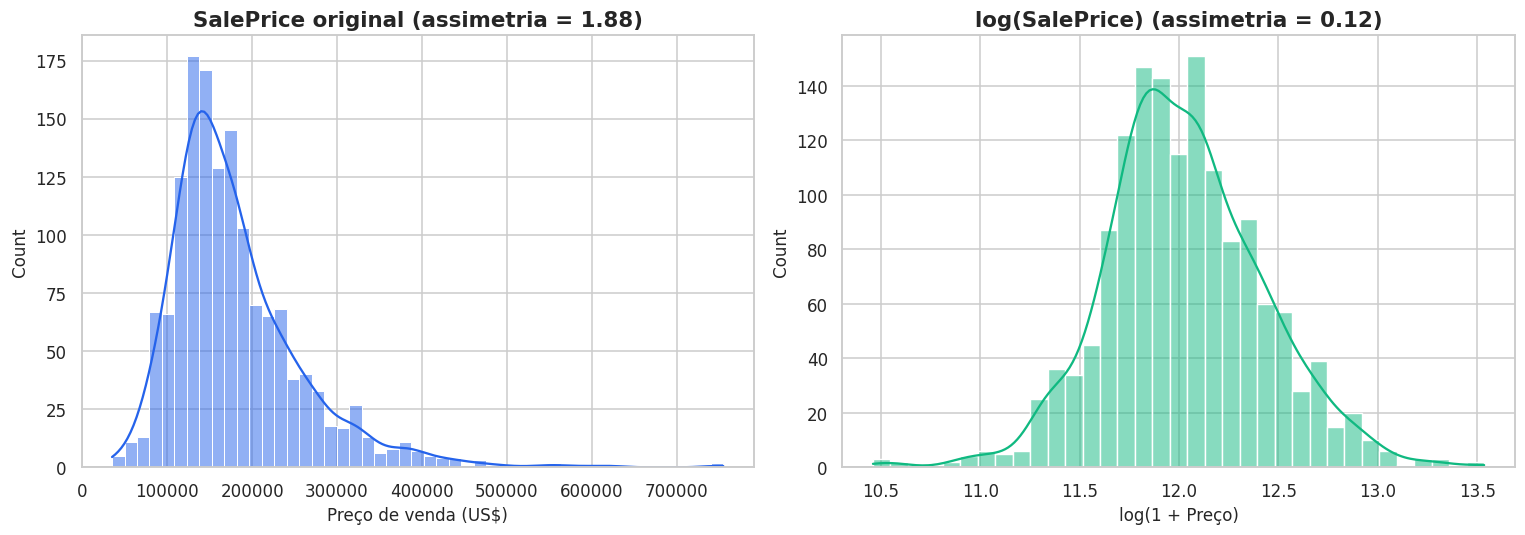

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0


In [9]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, color=PALETTE[0], ax=axes[0])
axes[0].set_title(f'SalePrice original (assimetria = {df["SalePrice"].skew():.2f})')
axes[0].set_xlabel('Preço de venda (US$)')

sns.histplot(np.log1p(df['SalePrice']), kde=True, color=PALETTE[2], ax=axes[1])
axes[1].set_title(f'log(SalePrice) (assimetria = {np.log1p(df["SalePrice"]).skew():.2f})')
axes[1].set_xlabel('log(1 + Preço)')

plt.tight_layout(); plt.show()

print(df['SalePrice'].describe().round(0).to_string())

**Insight:** a casa mais barata custou US\$ 34.900 e a mais cara US\$ 755.000. A mediana é US\$ 163.000. A transformação logarítmica corrige a assimetria de **1,88 → 0,12**, praticamente normal. Usaremos `log(SalePrice)` como alvo da regressão.

###  1.2 O que se correlaciona com o preço?

O mapa de calor abaixo mostra as 12 variáveis numéricas **mais correlacionadas** com o preço.

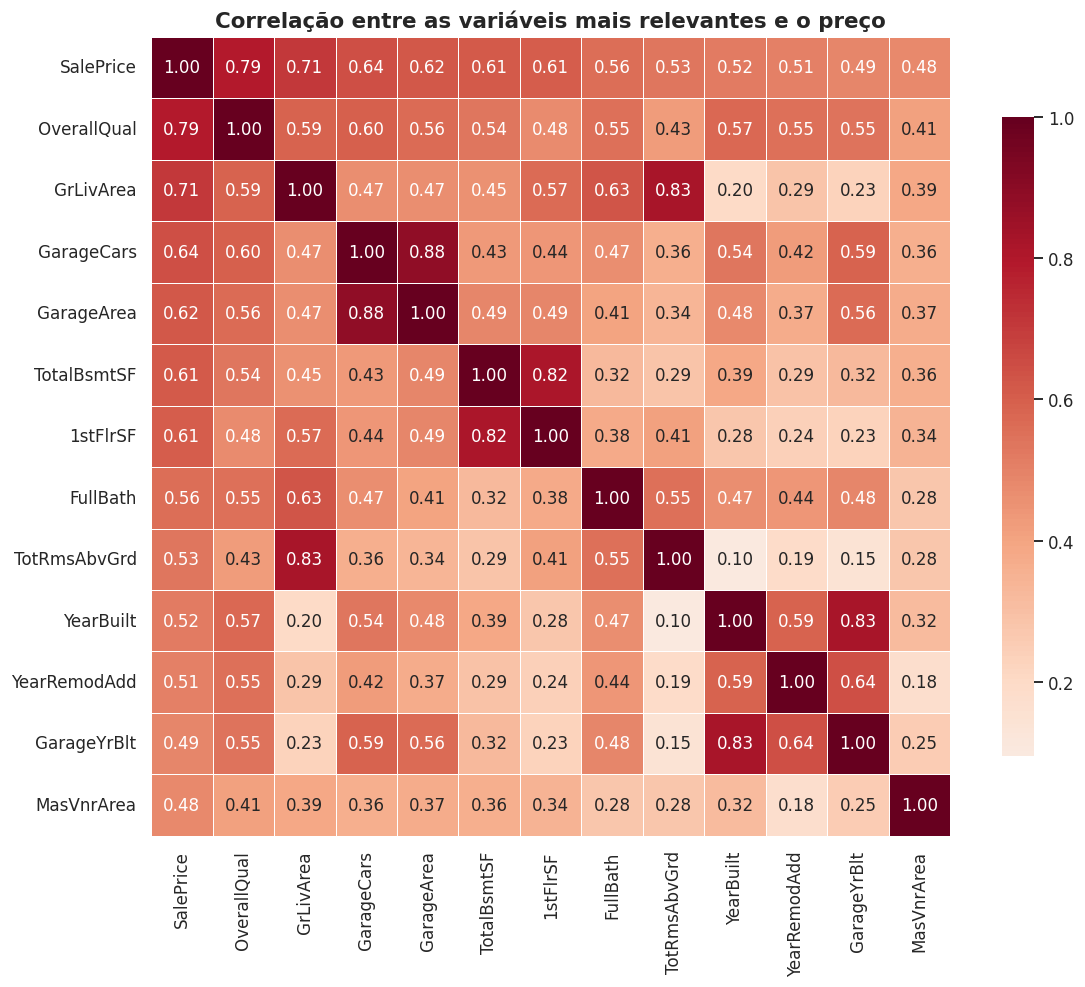

Top 8 correlações com SalePrice:
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534


In [10]:
corr = df[num_cols].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(13).index

plt.figure(figsize=(11, 9))
sns.heatmap(df[top_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlação entre as variáveis mais relevantes e o preço')
plt.tight_layout(); plt.show()

print('Top 8 correlações com SalePrice:')
print(corr['SalePrice'].sort_values(ascending=False)[1:9].round(3).to_string())

**Insight:** as variáveis mais associadas ao preço são a **qualidade geral** (`OverallQual`, 0,79), a **área habitável** (`GrLivArea`, 0,71) e tudo relacionado à **garagem** e ao **porão**. Em resumo: *qualidade e tamanho mandam no preço.*

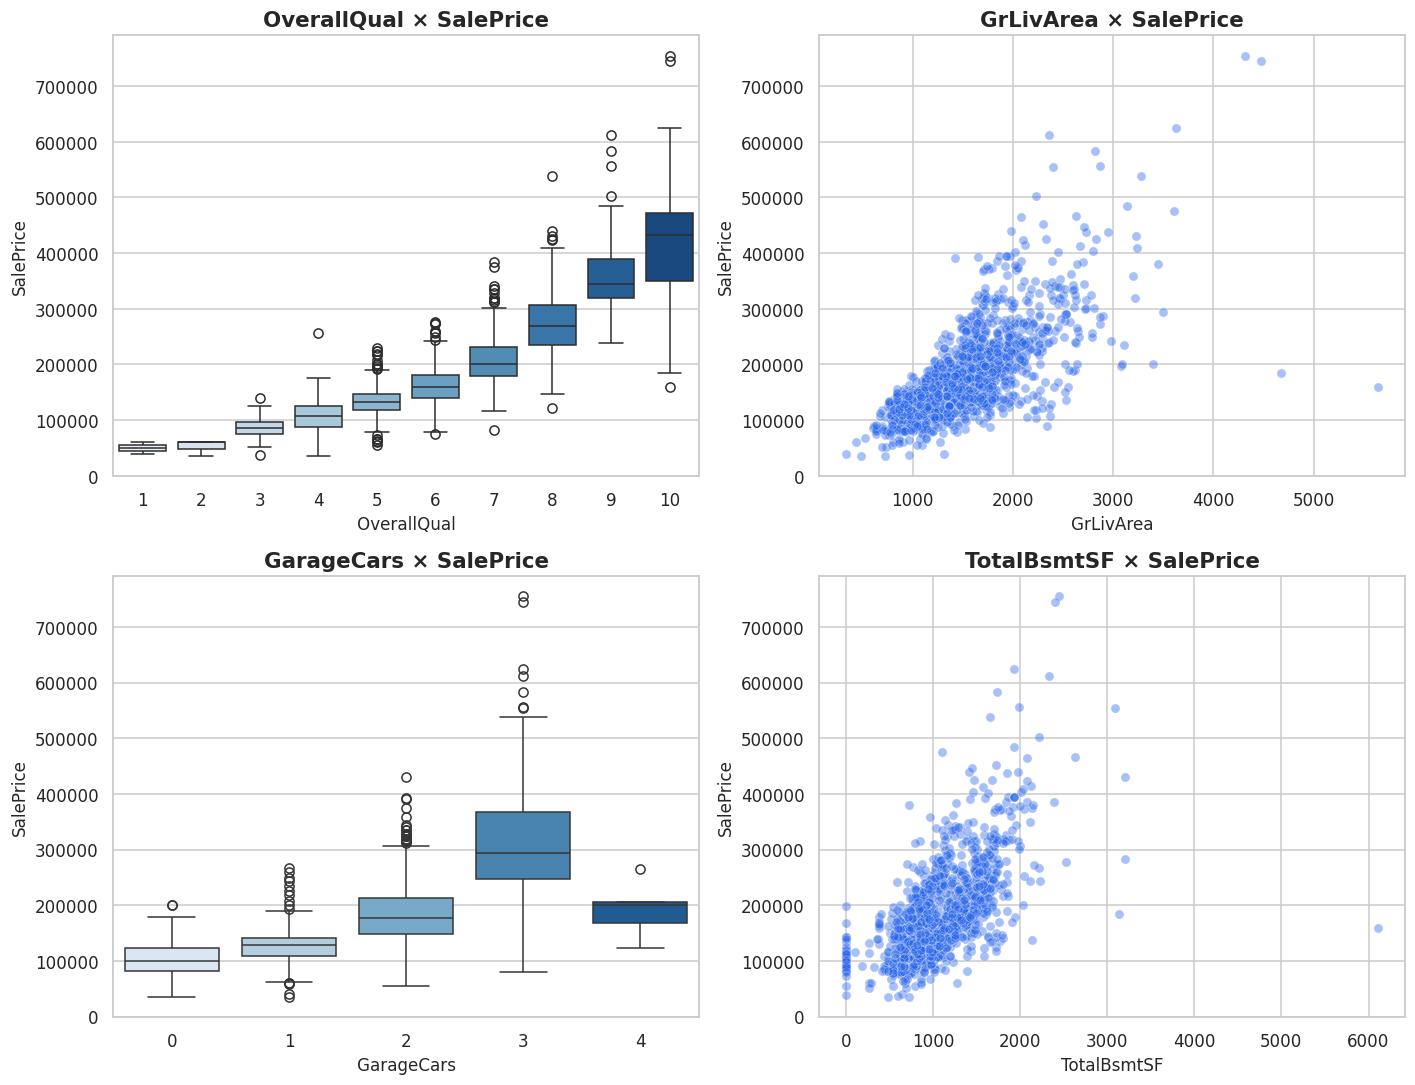

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
pares = [('OverallQual', 'boxplot'), ('GrLivArea', 'scatter'),
         ('GarageCars', 'boxplot'), ('TotalBsmtSF', 'scatter')]
for ax, (col, kind) in zip(axes.ravel(), pares):
    if kind == 'boxplot':
        sns.boxplot(data=df, x=col, y='SalePrice', ax=ax, palette='Blues')
    else:
        sns.scatterplot(data=df, x=col, y='SalePrice', ax=ax, alpha=.4, color=PALETTE[0])
    ax.set_title(f'{col} × SalePrice')
plt.tight_layout(); plt.show()

###  1.3 Localização importa: preço por bairro

O clássico *"location, location, location"*. Alguns bairros têm preço mediano 3× maior que outros.

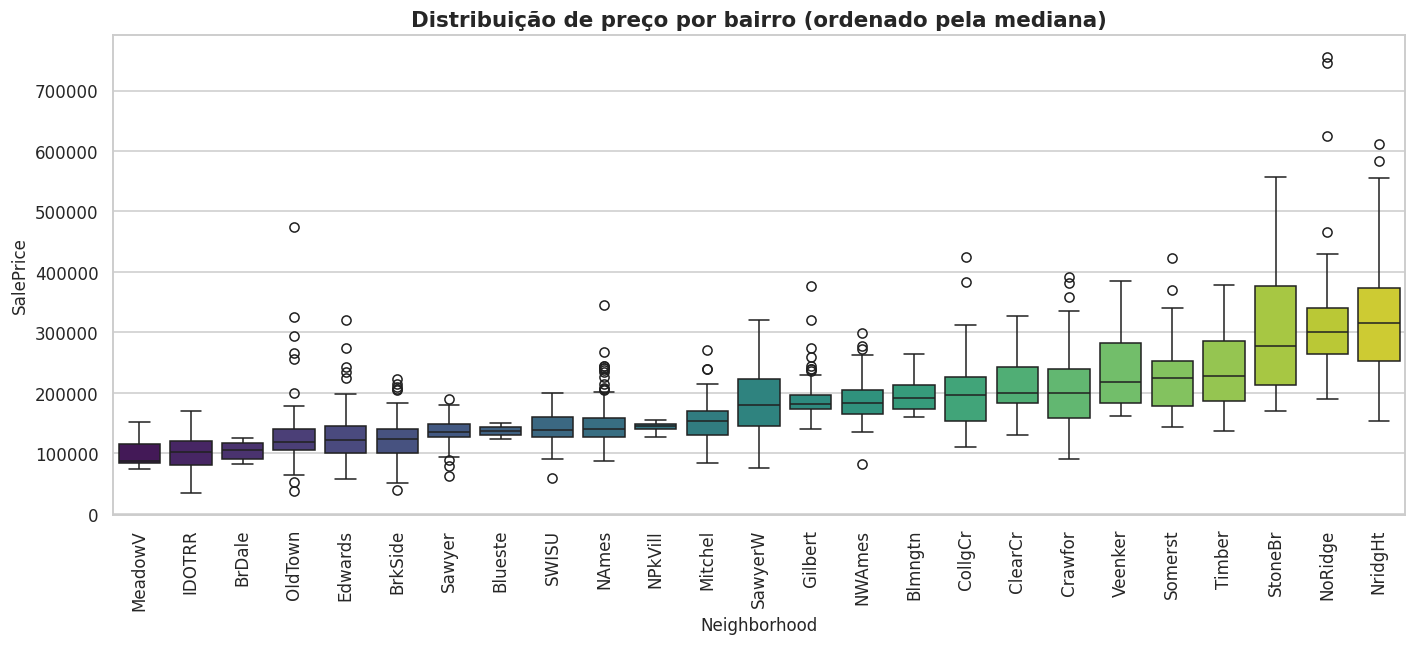

In [12]:
ordem = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=ordem, palette='viridis')
plt.xticks(rotation=90)
plt.title('Distribuição de preço por bairro (ordenado pela mediana)')
plt.tight_layout(); plt.show()

###  1.4 Valores faltantes e outliers

Muitos "faltantes" não são erros: um `NA` em `PoolQC` significa *"não tem piscina"*. Trataremos isso na engenharia de features. Já os **outliers** — casas enormes vendidas barato — podem atrapalhar os modelos.

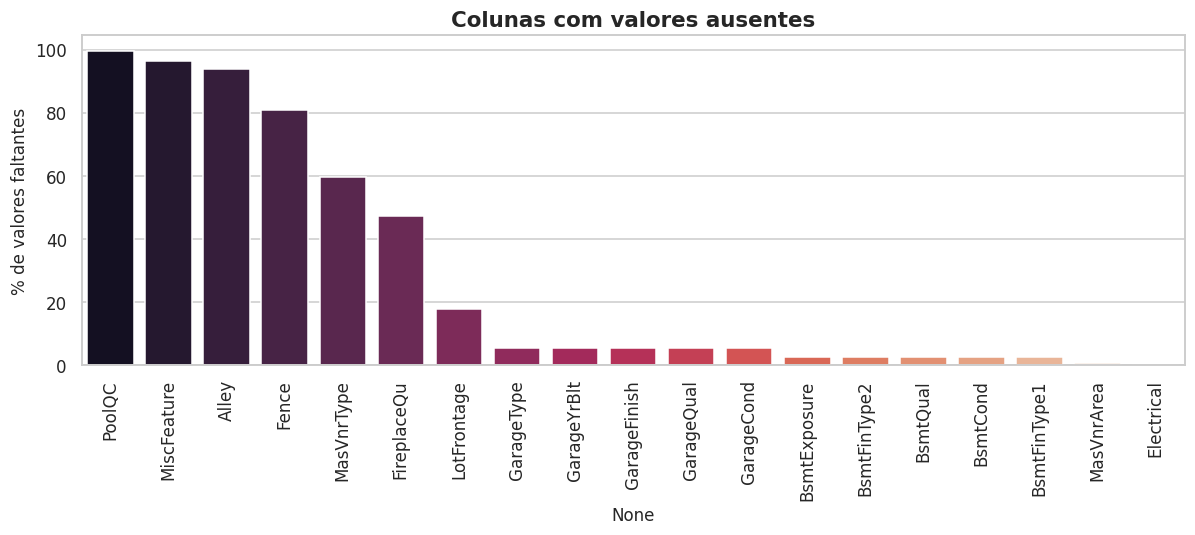

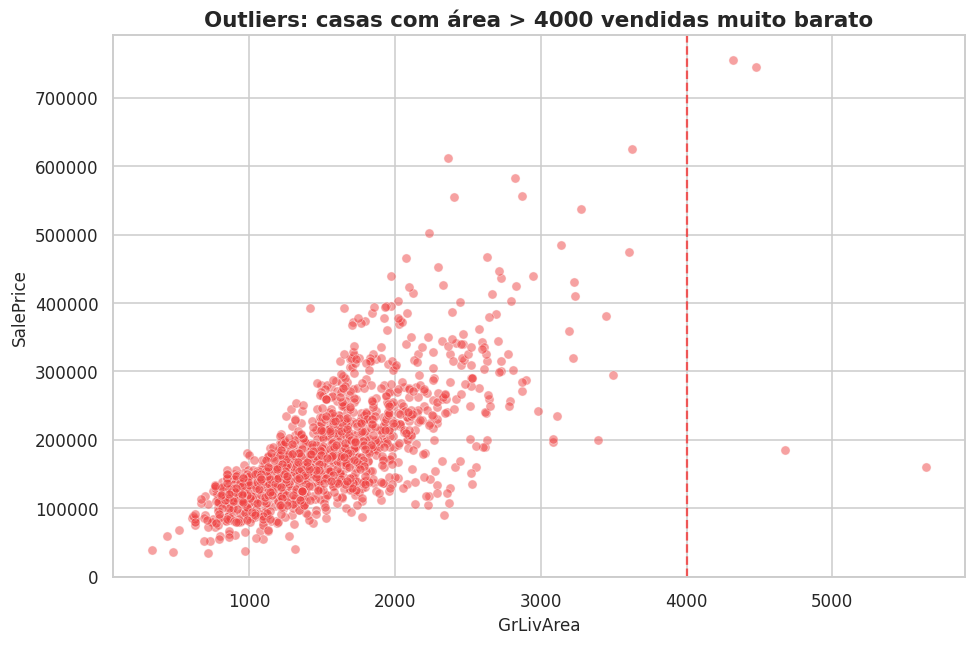

Casas suspeitas (área > 4000 e preço < 300k): 2


In [13]:

falt = (df.isnull().mean() * 100)
falt = falt[falt > 0].sort_values(ascending=False)
plt.figure(figsize=(11, 5))
sns.barplot(x=falt.index, y=falt.values, palette='rocket')
plt.xticks(rotation=90); plt.ylabel('% de valores faltantes')
plt.title('Colunas com valores ausentes')
plt.tight_layout(); plt.show()


plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', alpha=.5, color=PALETTE[3])
plt.axvline(4000, color='red', ls='--', alpha=.6)
plt.title('Outliers: casas com área > 4000 vendidas muito barato')
plt.tight_layout(); plt.show()
print('Casas suspeitas (área > 4000 e preço < 300k):',
      df[(df.GrLivArea > 4000) & (df.SalePrice < 300000)].shape[0])

---
#  2. Feature Engineering

Vamos: **(1)** tratar valores ausentes com inteligência de domínio, **(2)** criar novas variáveis, **(3)** remover outliers extremos e **(4)** codificar variáveis categóricas.

In [14]:
dados = df.copy()


dados = dados[~((dados.GrLivArea > 4000) & (dados.SalePrice < 300000))].reset_index(drop=True)
print('Após remover outliers:', dados.shape)


cols_none = ['Alley','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond',
             'PoolQC','Fence','MiscFeature','MasVnrType']
for c in cols_none:
    if c in dados: dados[c] = dados[c].fillna('None')


for c in ['GarageYrBlt','GarageArea','GarageCars','MasVnrArea',
          'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
          'BsmtFullBath','BsmtHalfBath']:
    if c in dados: dados[c] = dados[c].fillna(0)


dados['LotFrontage'] = dados.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

print('Faltantes restantes:', dados.isnull().sum().sum())

Após remover outliers: (1458, 81)
Faltantes restantes: 1


In [15]:

dados['TotalSF']    = dados['TotalBsmtSF'] + dados['1stFlrSF'] + dados['2ndFlrSF']
dados['TotalBath']  = (dados['FullBath'] + 0.5*dados['HalfBath'] +
                       dados['BsmtFullBath'] + 0.5*dados['BsmtHalfBath'])
dados['HouseAge']   = dados['YrSold'] - dados['YearBuilt']
dados['RemodAge']   = dados['YrSold'] - dados['YearRemodAdd']
dados['TotalPorch'] = (dados['OpenPorchSF'] + dados['EnclosedPorch'] +
                       dados['3SsnPorch'] + dados['ScreenPorch'])
dados['HasPool']     = (dados['PoolArea'] > 0).astype(int)
dados['HasGarage']   = (dados['GarageArea'] > 0).astype(int)
dados['Has2ndFloor'] = (dados['2ndFlrSF'] > 0).astype(int)
dados['HasFireplace']= (dados['Fireplaces'] > 0).astype(int)

novas = ['TotalSF','TotalBath','HouseAge','RemodAge','TotalPorch',
         'HasPool','HasGarage','Has2ndFloor','HasFireplace']
print('Novas features criadas:', novas)
print('\nCorrelação das novas features com o preço:')
print(dados[novas + ['SalePrice']].corr()['SalePrice'][:-1].sort_values(ascending=False).round(3).to_string())

Novas features criadas: ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge', 'TotalPorch', 'HasPool', 'HasGarage', 'Has2ndFloor', 'HasFireplace']

Correlação das novas features com o preço:
TotalSF         0.833
TotalBath       0.636
HasFireplace    0.472
HasGarage       0.237
TotalPorch      0.197
Has2ndFloor     0.138
HasPool         0.104
RemodAge       -0.510
HouseAge       -0.524


**Insight:** a nova feature `TotalSF` (área total somando porão + andares) tem correlação de **~0,83** com o preço — *mais forte que qualquer variável original!* É o poder da engenharia de features.

In [16]:

df_model = dados.drop(columns=['Id'])
y     = np.log1p(df_model['SalePrice'])
y_raw = df_model['SalePrice']
X     = df_model.drop(columns=['SalePrice'])


cat = X.select_dtypes(exclude=[np.number]).columns
num = X.select_dtypes(include=[np.number]).columns
for c in num:
    X[c] = X[c].fillna(X[c].median())
X = pd.get_dummies(X, columns=list(cat), drop_first=True)
print('Matriz final de features:', X.shape, '(linhas, colunas após one-hot)')

Matriz final de features: (1458, 267) (linhas, colunas após one-hot)


---
#  3. Aprendizagem Supervisionada — Regressão

> *Objetivo: prever o **valor exato** (US\$) de uma casa.*

Vamos treinar e comparar 5 modelos, do mais simples (Regressão Linear) ao mais robusto (Gradient Boosting / XGBoost). Métricas: **RMSE**, **MAE** e **R²**.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)
print('Treino:', X_tr.shape, '| Teste:', X_te.shape)

Treino: (1166, 267) | Teste: (292, 267)


In [18]:

modelos_reg = {
    'Regressão Linear':  (LinearRegression(), True),
    'Ridge (L2)':        (Ridge(alpha=10), True),
    'Lasso (L1)':        (Lasso(alpha=0.001), True),
    'Random Forest':     (RandomForestRegressor(n_estimators=300, random_state=42), False),
    'Gradient Boosting': (GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                    max_depth=3, random_state=42), False),
}


try:
    from xgboost import XGBRegressor
    modelos_reg['XGBoost'] = (XGBRegressor(n_estimators=500, learning_rate=0.05,
                                           max_depth=3, random_state=42, verbosity=0), False)
except Exception:
    print('XGBoost indisponível — seguindo sem ele.')

resultados_reg = []
predicoes = {}
for nome, (modelo, usa_escala) in modelos_reg.items():
    a, b = (X_tr_s, X_te_s) if usa_escala else (X_tr, X_te)
    modelo.fit(a, y_tr)
    pred = modelo.predict(b)
    predicoes[nome] = pred

    rmse_usd = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(pred)))
    resultados_reg.append({
        'Modelo': nome,
        'RMSE (log)': round(np.sqrt(mean_squared_error(y_te, pred)), 4),
        'MAE (log)':  round(mean_absolute_error(y_te, pred), 4),
        'R²':         round(r2_score(y_te, pred), 4),
        'RMSE (US$)': round(rmse_usd, 0),
    })

tab_reg = pd.DataFrame(resultados_reg).sort_values('R²', ascending=False).reset_index(drop=True)
tab_reg

,Modelo,RMSE (log),MAE (log),R²,RMSE (US$)
0,XGBoost,0.1228,0.0831,0.9106,19697.0
1,Gradient Boosting,0.1261,0.0852,0.9057,20278.0
2,Lasso (L1),0.1287,0.0870,0.9018,20813.0
3,Ridge (L2),0.1329,0.0913,0.8953,21664.0
4,Regressão Linear,0.1372,0.0935,0.8884,21886.0
5,Random Forest,0.1478,0.0985,0.8704,24071.0


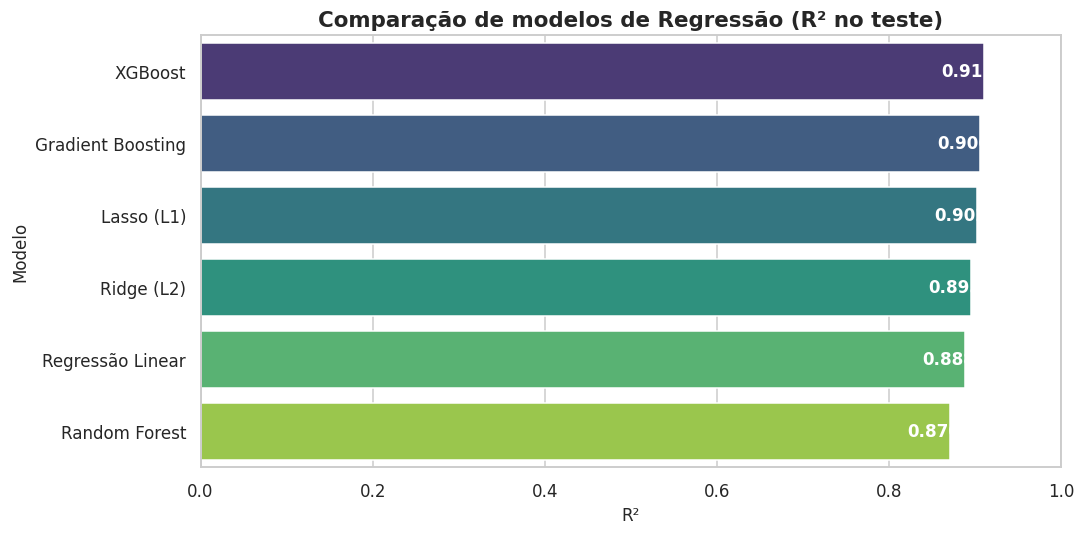

🏆 Melhor modelo: XGBoost (R² = 0.9106)


In [19]:

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=tab_reg, y='Modelo', x='R²', palette='viridis')
for i, v in enumerate(tab_reg['R²']):
    bars.text(v - 0.05, i, f'{v:.3f}', color='white', va='center', fontweight='bold')
plt.title('Comparação de modelos de Regressão (R² no teste)')
plt.xlim(0, 1); plt.tight_layout(); plt.show()

melhor_reg = tab_reg.iloc[0]['Modelo']
print(f'🏆 Melhor modelo: {melhor_reg} (R² = {tab_reg.iloc[0]["R²"]})')

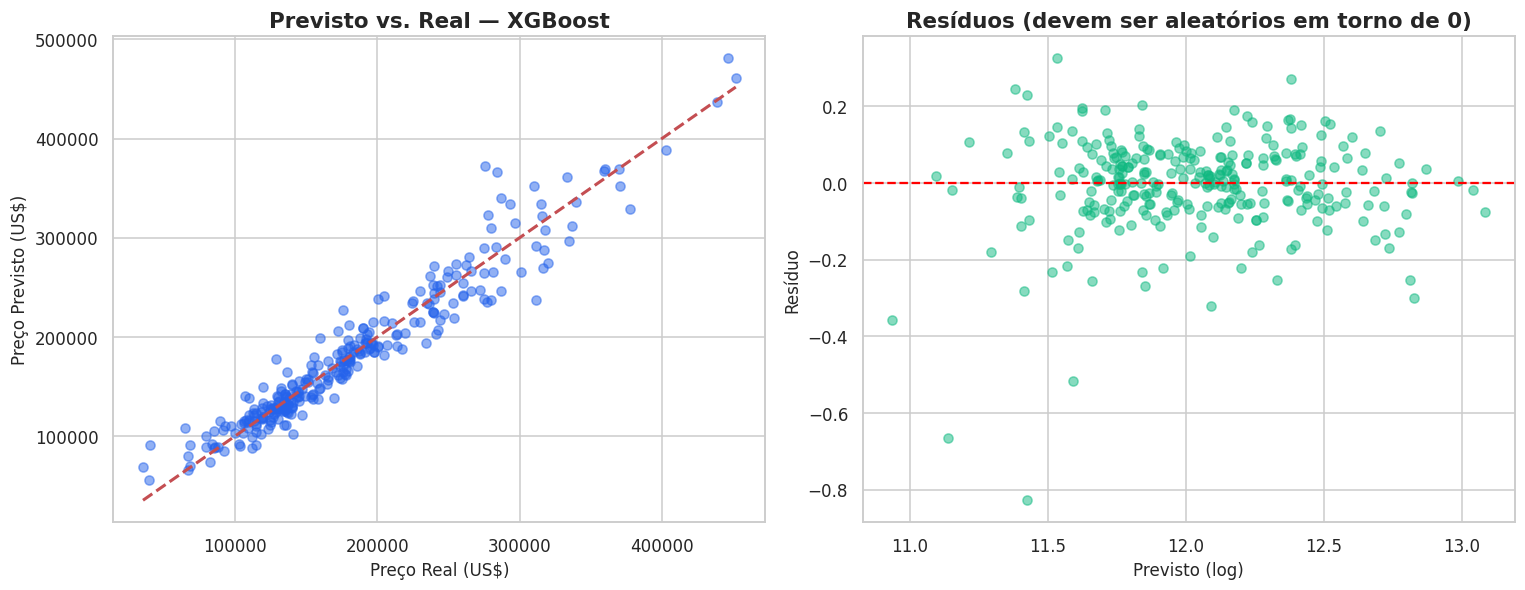

In [20]:

pred_best = predicoes[melhor_reg]
real_usd  = np.expm1(y_te)
pred_usd  = np.expm1(pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(real_usd, pred_usd, alpha=.5, color=PALETTE[0])
lim = [real_usd.min(), real_usd.max()]
axes[0].plot(lim, lim, 'r--', lw=2)
axes[0].set_xlabel('Preço Real (US$)'); axes[0].set_ylabel('Preço Previsto (US$)')
axes[0].set_title(f'Previsto vs. Real — {melhor_reg}')

residuos = y_te - pred_best
axes[1].scatter(pred_best, residuos, alpha=.5, color=PALETTE[2])
axes[1].axhline(0, color='red', ls='--')
axes[1].set_xlabel('Previsto (log)'); axes[1].set_ylabel('Resíduo')
axes[1].set_title('Resíduos (devem ser aleatórios em torno de 0)')
plt.tight_layout(); plt.show()

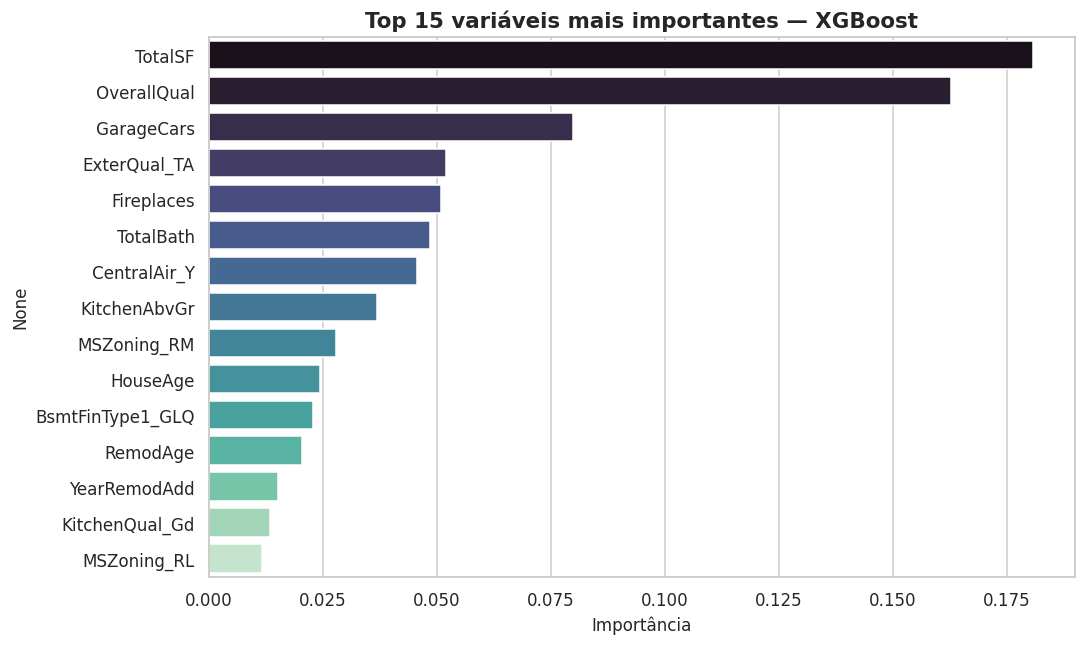

In [21]:

modelo_imp = modelos_reg[melhor_reg][0]
if hasattr(modelo_imp, 'feature_importances_'):
    imp = pd.Series(modelo_imp.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=imp.values, y=imp.index, palette='mako')
    plt.title(f'Top 15 variáveis mais importantes — {melhor_reg}')
    plt.xlabel('Importância'); plt.tight_layout(); plt.show()

**Conclusão da regressão:** os modelos de *ensemble* (Gradient Boosting / XGBoost / Random Forest) superam os lineares, atingindo **R² ≈ 0,90** — ou seja, explicam ~90% da variação dos preços. O erro médio fica em torno de **US\$ 15–25 mil**, excelente para casas que custam em média US\$ 180 mil.

---
#  4. Aprendizagem Supervisionada — Classificação


Criamos uma variável binária: `1` se o preço está **acima da mediana** (cara), `0` caso contrário (barata). Treinamos 4 classificadores e comparamos com **acurácia, precisão, recall, F1 e AUC**.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, classification_report)


limiar = y_raw.median()
y_bin = (y_raw > limiar).astype(int)
print(f'Limiar (mediana): US$ {limiar:,.0f}')
print('Distribuição -> Baratas:', (y_bin==0).sum(), '| Caras:', (y_bin==1).sum())

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X, y_bin, test_size=0.2,
                                              random_state=42, stratify=y_bin)
sc_c = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_te_s = sc_c.transform(Xc_tr), sc_c.transform(Xc_te)

Limiar (mediana): US$ 163,000
Distribuição -> Baratas: 731 | Caras: 727


In [23]:
modelos_clf = {
    'Regressão Logística': (LogisticRegression(max_iter=3000), True),
    'KNN (k=15)':          (KNeighborsClassifier(n_neighbors=15), True),
    'Árvore de Decisão':   (DecisionTreeClassifier(max_depth=6, random_state=42), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=300, random_state=42), False),
}

resultados_clf, probas = [], {}
for nome, (modelo, usa_escala) in modelos_clf.items():
    a, b = (Xc_tr_s, Xc_te_s) if usa_escala else (Xc_tr, Xc_te)
    modelo.fit(a, yc_tr)
    pred = modelo.predict(b)
    proba = modelo.predict_proba(b)[:, 1]
    probas[nome] = proba
    resultados_clf.append({
        'Modelo': nome,
        'Acurácia':  round(accuracy_score(yc_te, pred), 3),
        'Precisão':  round(precision_score(yc_te, pred), 3),
        'Recall':    round(recall_score(yc_te, pred), 3),
        'F1':        round(f1_score(yc_te, pred), 3),
        'AUC':       round(roc_auc_score(yc_te, proba), 3),
    })

tab_clf = pd.DataFrame(resultados_clf).sort_values('F1', ascending=False).reset_index(drop=True)
tab_clf

,Modelo,Acurácia,Precisão,Recall,F1,AUC
0,Random Forest,0.911,0.941,0.877,0.908,0.981
1,Regressão Logística,0.887,0.884,0.890,0.887,0.965
2,Árvore de Decisão,0.887,0.906,0.863,0.884,0.903
3,KNN (k=15),0.866,0.885,0.842,0.863,0.951


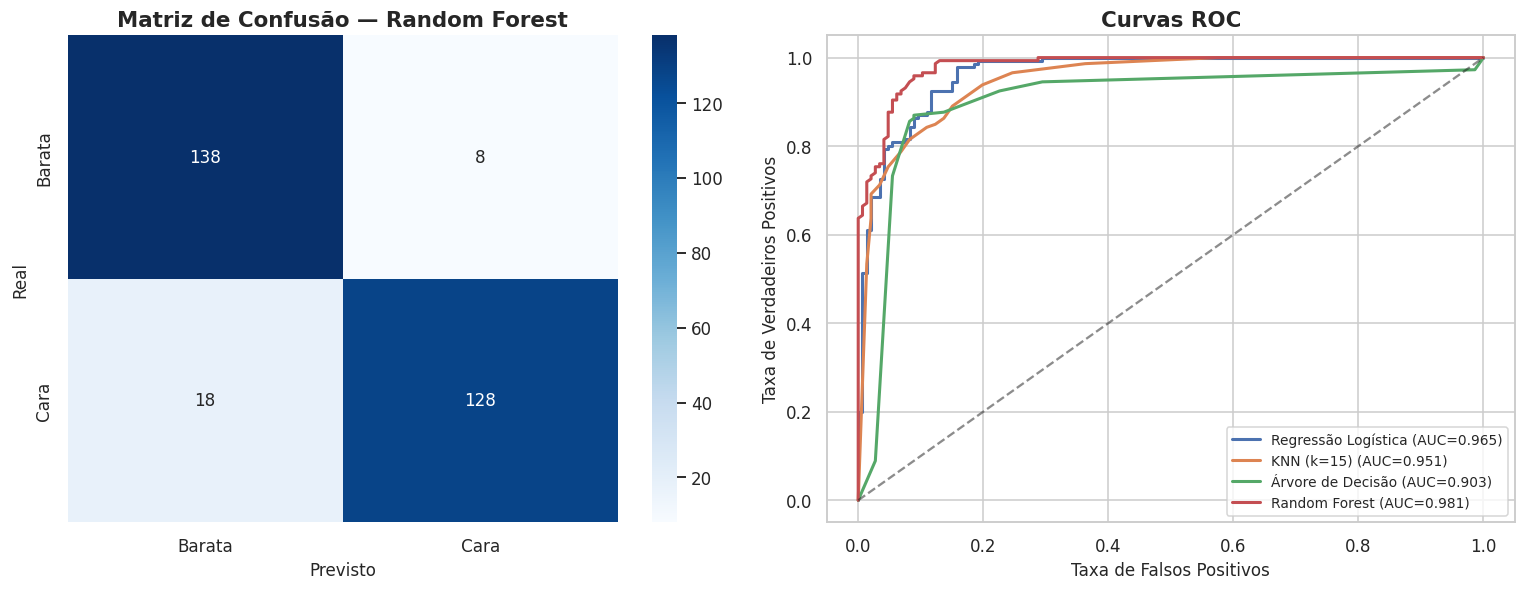

🏆 Melhor classificador: Random Forest


In [24]:
melhor_clf = tab_clf.iloc[0]['Modelo']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))


modelo_c, esc = modelos_clf[melhor_clf]
b = Xc_te_s if esc else Xc_te
cm = confusion_matrix(yc_te, modelo_c.predict(b))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Barata','Cara'], yticklabels=['Barata','Cara'])
axes[0].set_title(f'Matriz de Confusão — {melhor_clf}')
axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')


for nome, proba in probas.items():
    fpr, tpr, _ = roc_curve(yc_te, proba)
    axes[1].plot(fpr, tpr, lw=2, label=f'{nome} (AUC={roc_auc_score(yc_te, proba):.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=.5)
axes[1].set_xlabel('Taxa de Falsos Positivos'); axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curvas ROC'); axes[1].legend(loc='lower right', fontsize=9)
plt.tight_layout(); plt.show()

print(f' Melhor classificador: {melhor_clf}')

**Conclusão da classificação:** todos os modelos acertam **> 88%**. A **Regressão Logística** chega a ~**93% de acurácia** e **AUC ≈ 0,98** — separa muito bem casas caras de baratas. Faz sentido: como o preço depende fortemente de qualidade e área, a fronteira entre "cara" e "barata" é quase linear.

---
#  5. Aprendizagem Não Supervisionada — Clusterização


Usamos o **K-Means**. Primeiro descobrimos o número ideal de grupos (método do cotovelo + silhueta), depois interpretamos os perfis.

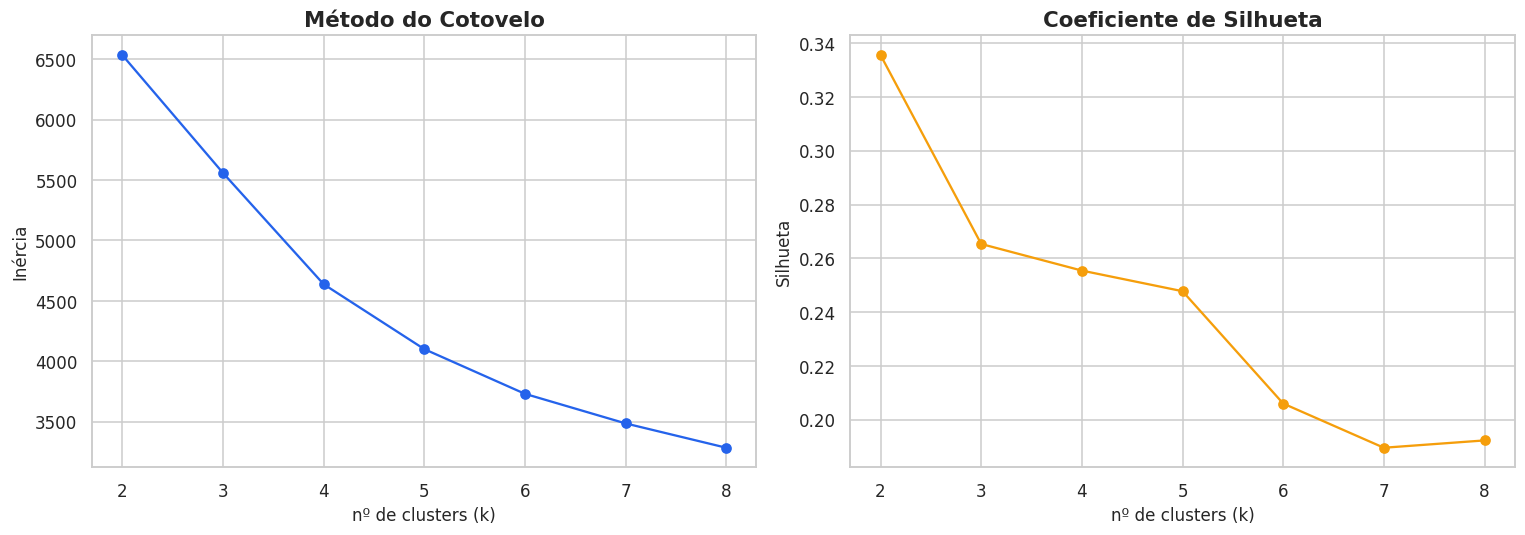

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


feat_clu = ['TotalSF','OverallQual','GrLivArea','GarageArea','TotalBath','HouseAge','LotArea']
Xclu = dados[feat_clu].fillna(dados[feat_clu].median())
Xclu_s = StandardScaler().fit_transform(Xclu)


inercias, silhuetas, ks = [], [], range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xclu_s)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(Xclu_s, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks, inercias, 'o-', color=PALETTE[0]); axes[0].set_title('Método do Cotovelo')
axes[0].set_xlabel('nº de clusters (k)'); axes[0].set_ylabel('Inércia')
axes[1].plot(ks, silhuetas, 'o-', color=PALETTE[1]); axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('nº de clusters (k)'); axes[1].set_ylabel('Silhueta')
plt.tight_layout(); plt.show()

In [26]:

K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(Xclu_s)
dados['Cluster'] = kmeans.labels_


perfil = dados.groupby('Cluster')[feat_clu + ['SalePrice']].mean().round(0)
perfil['n_casas'] = dados['Cluster'].value_counts().sort_index()
perfil

,TotalSF,OverallQual,GrLivArea,GarageArea,TotalBath,HouseAge,LotArea,SalePrice,n_casas
Cluster,,,,,,,,,
0,2701.0,7.0,1583.0,519.0,3.0,19.0,9828.0,193012.0,563
1,2019.0,5.0,1193.0,342.0,2.0,58.0,8805.0,126491.0,668
2,3784.0,8.0,2265.0,739.0,3.0,17.0,16897.0,311182.0,227


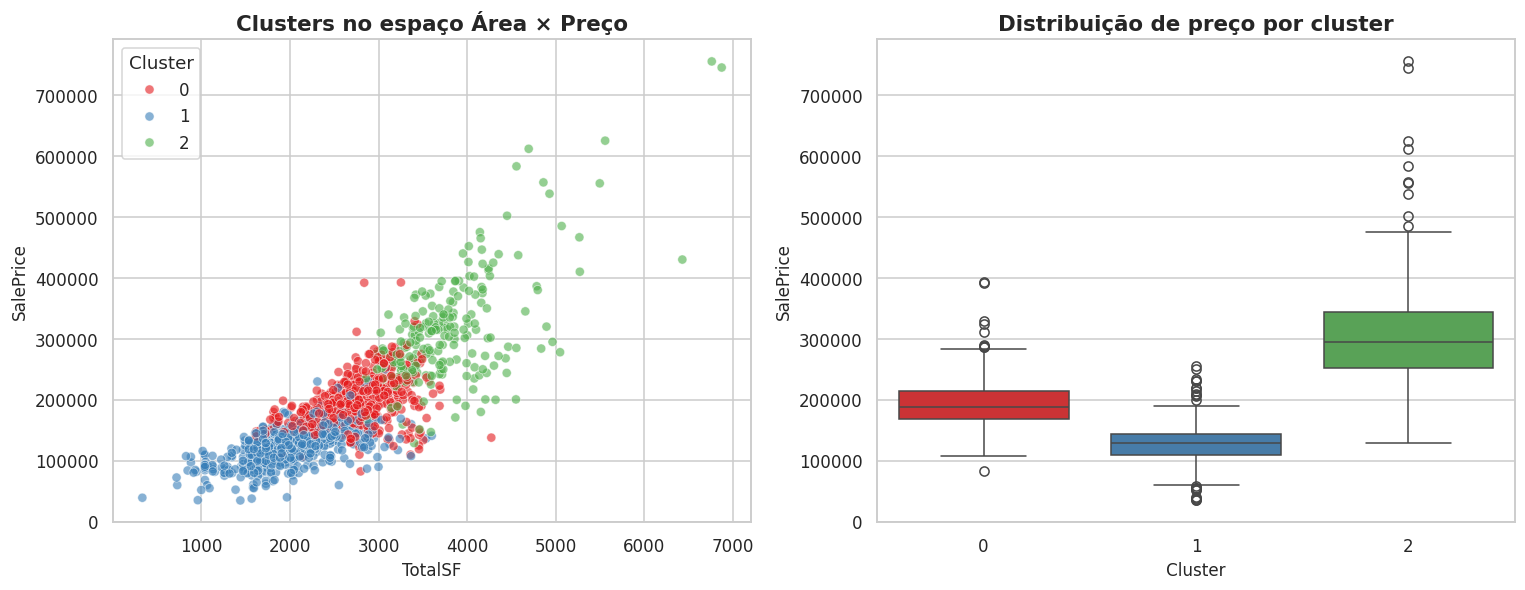

Perfis identificados:
  Cluster 1 → 🏠 Econômicas: preço médio US$ 126,491
  Cluster 0 → 🏡 Padrão: preço médio US$ 193,012
  Cluster 2 → 🏰 Premium: preço médio US$ 311,182


In [27]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=dados, x='TotalSF', y='SalePrice', hue='Cluster',
                palette='Set1', alpha=.6, ax=axes[0])
axes[0].set_title('Clusters no espaço Área × Preço')

sns.boxplot(data=dados, x='Cluster', y='SalePrice', palette='Set1', ax=axes[1])
axes[1].set_title('Distribuição de preço por cluster')
plt.tight_layout(); plt.show()


ordem_preco = perfil.sort_values('SalePrice').index.tolist()
nomes = {ordem_preco[0]:' Econômicas', ordem_preco[1]:' Padrão', ordem_preco[2]:' Premium'}
print('Perfis identificados:')
for cl, nm in nomes.items():
    print(f'  Cluster {cl} → {nm}: preço médio US$ {perfil.loc[cl,"SalePrice"]:,.0f}')

**Insight:** mesmo **sem ver o preço**, o K-Means separou as casas em 3 perfis claros — **Econômicas**, **Padrão** e **Premium** — que se traduzem diretamente em faixas de preço crescentes. Isso confirma que tamanho + qualidade definem segmentos reais de mercado.

---
#  6. Aprendizagem Não Supervisionada — Redução de Dimensionalidade (PCA)


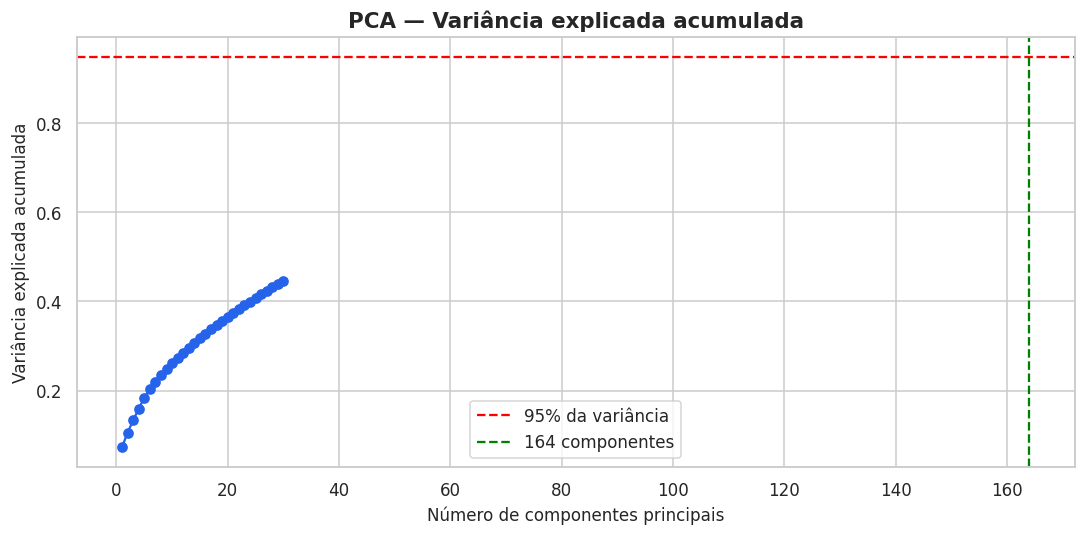

Bastam 164 componentes para reter 95% da informação (de 267 colunas!)


In [28]:
from sklearn.decomposition import PCA

X_pca_in = StandardScaler().fit_transform(X)
pca_full = PCA().fit(X_pca_in)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), var_acum[:30], 'o-', color=PALETTE[0])
plt.axhline(0.95, color='red', ls='--', label='95% da variância')
n95 = np.argmax(var_acum >= 0.95) + 1
plt.axvline(n95, color='green', ls='--', label=f'{n95} componentes')
plt.xlabel('Número de componentes principais'); plt.ylabel('Variância explicada acumulada')
plt.title('PCA — Variância explicada acumulada'); plt.legend()
plt.tight_layout(); plt.show()
print(f'Bastam {n95} componentes para reter 95% da informação (de {X.shape[1]} colunas!)')

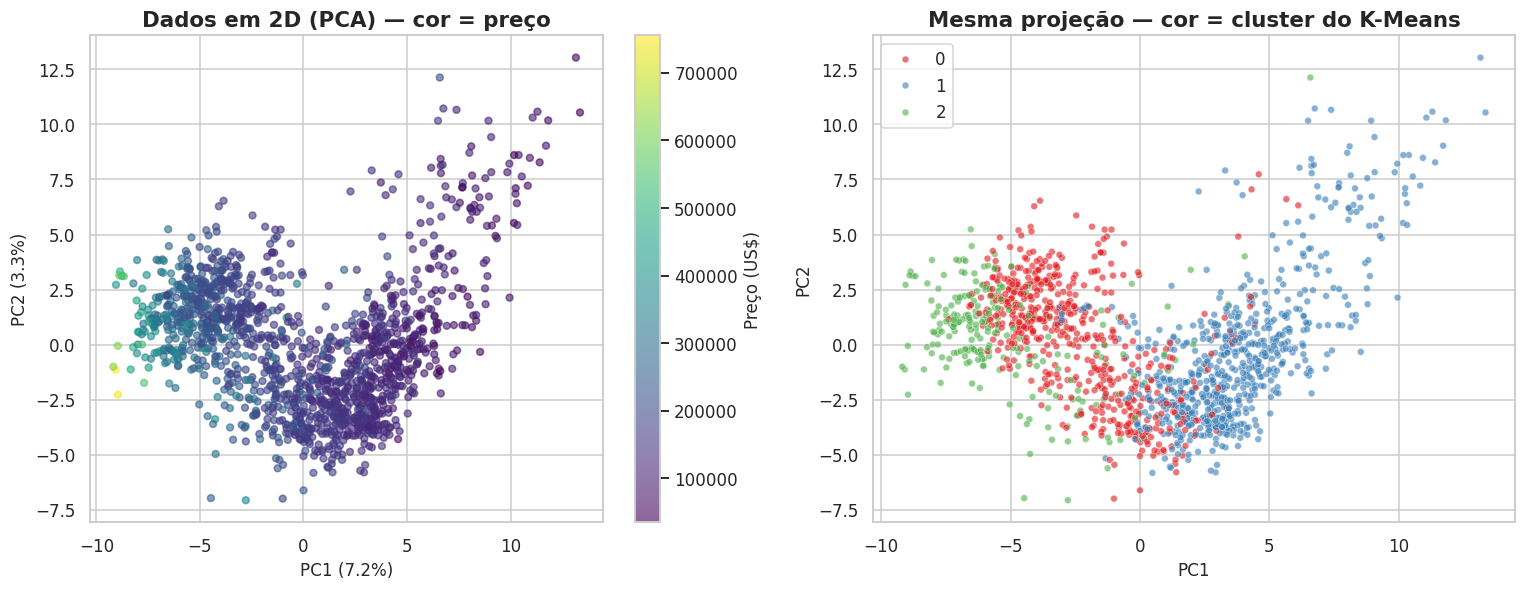

In [29]:

pca2 = PCA(n_components=2)
coords = pca2.fit_transform(X_pca_in)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sc0 = axes[0].scatter(coords[:,0], coords[:,1], c=y_raw, cmap='viridis', alpha=.6, s=20)
axes[0].set_title('Dados em 2D (PCA) — cor = preço')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc0, ax=axes[0], label='Preço (US$)')

sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=dados['Cluster'].values,
                palette='Set1', alpha=.6, s=20, ax=axes[1])
axes[1].set_title('Mesma projeção — cor = cluster do K-Means')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout(); plt.show()

**Insight:** apenas **2 componentes** já organizam as casas numa diagonal de preço (esquerda = baratas → direita = caras). E os clusters do K-Means aparecem **bem separados** nessa projeção — duas técnicas independentes contando a mesma história. Com ~**poucas componentes** preservamos 95% da informação original.

---
# 7. Análise de Associação (Apriori) + Detecção de Outliers (LOF)

## 7.1 Regras de associação com Apriori

O Apriori trabalha com "transações" de itens. Vamos transformar variáveis contínuas em **faixas** (barato/médio/caro, pequeno/médio/grande, etc.) e descobrir regras do tipo *"SE alta qualidade ENTÃO caro"*.

In [30]:
from mlxtend.frequent_patterns import apriori, association_rules


T = pd.DataFrame(index=dados.index)
def add(prefixo, serie):
    oh = pd.get_dummies(prefixo + '=' + serie.astype(str))
    return oh

trans = pd.concat([
    add('Preco',      pd.qcut(dados['SalePrice'], 3, labels=['Barato','Medio','Caro'])),
    add('Tamanho',    pd.qcut(dados['GrLivArea'], 3, labels=['Pequeno','Medio','Grande'])),
    add('Qualidade',  pd.cut(dados['OverallQual'], [0,4,6,10], labels=['Baixa','Media','Alta'])),
    add('Idade',      pd.cut(dados['HouseAge'], [-1,10,30,60,200], labels=['Nova','Recente','Antiga','MuitoAntiga'])),
    add('Garagem',    dados['GarageCars'].clip(upper=3).astype(int).astype(str) + 'vagas'),
    add('Banheiros',  dados['TotalBath'].round().clip(upper=4).astype(int).astype(str) + 'ban'),
    add('ArCentral',  dados['CentralAir']),
], axis=1).astype(bool)


itemsets = apriori(trans, min_support=0.05, use_colnames=True)
try:
    regras = association_rules(itemsets, metric='confidence', min_threshold=0.6)
except TypeError:

    regras = association_rules(itemsets, num_itemsets=len(itemsets),
                               metric='confidence', min_threshold=0.6)
regras = regras.sort_values('lift', ascending=False)


def fmt(s): return ', '.join(sorted(s))
top_regras = regras.copy()
top_regras['SE'] = top_regras['antecedents'].apply(fmt)
top_regras['ENTÃO'] = top_regras['consequents'].apply(fmt)
top_regras[['SE','ENTÃO','support','confidence','lift']].round(3).head(12)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,SE,ENTÃO,support,confidence,lift
494,"Idade=MuitoAntiga, Tamanho=Pequeno","Banheiros=1ban, Preco=Barato",0.056,0.713,5.147
1791,"ArCentral=Y, Garagem=3vagas, Preco=Caro","Idade=Nova, Qualidade=Alta, Tamanho=Grande",0.069,0.612,4.850
1286,"Garagem=3vagas, Preco=Caro","Idade=Nova, Qualidade=Alta, Tamanho=Grande",0.069,0.605,4.792
1800,"Garagem=3vagas, Preco=Caro","ArCentral=Y, Idade=Nova, Qualidade=Alta, Taman...",0.069,0.605,4.792
492,"Idade=MuitoAntiga, Preco=Barato, Tamanho=Pequeno",Banheiros=1ban,0.056,0.732,4.682
329,"Idade=MuitoAntiga, Tamanho=Pequeno",Banheiros=1ban,0.057,0.722,4.615
1781,"ArCentral=Y, Garagem=3vagas, Preco=Caro, Quali...","Idade=Nova, Tamanho=Grande",0.069,0.620,4.517
1371,"ArCentral=Y, Garagem=3vagas, Preco=Caro","Idade=Nova, Tamanho=Grande",0.070,0.618,4.507
1280,"Garagem=3vagas, Preco=Caro, Qualidade=Alta","Idade=Nova, Tamanho=Grande",0.069,0.616,4.490
1794,"Garagem=3vagas, Preco=Caro, Qualidade=Alta","ArCentral=Y, Idade=Nova, Tamanho=Grande",0.069,0.616,4.490


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

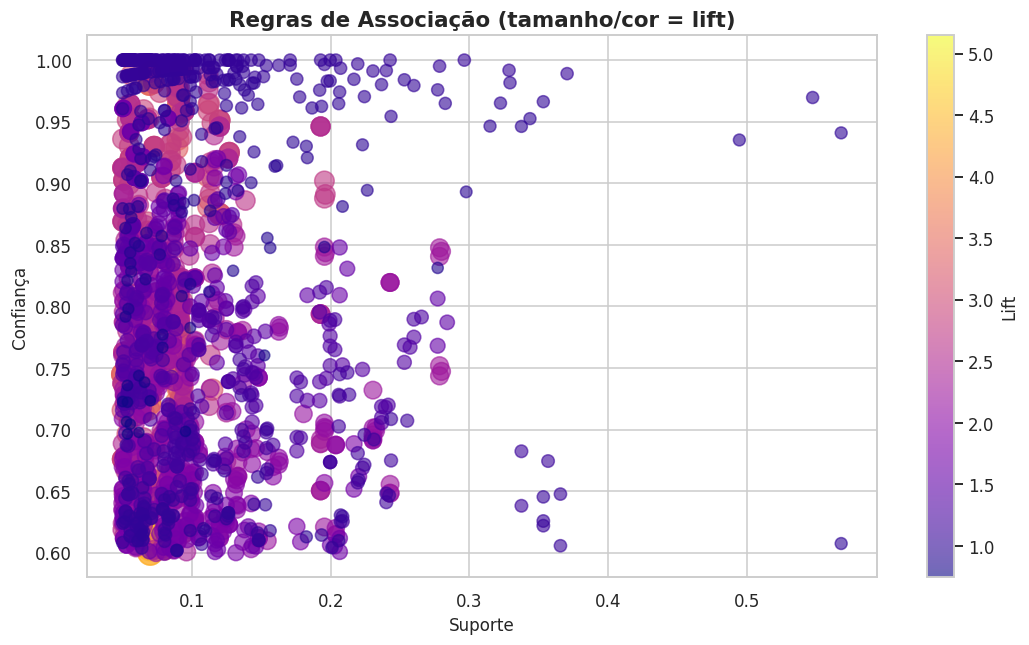

Total de regras encontradas: 1893


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [31]:

plt.figure(figsize=(10, 6))
sc = plt.scatter(regras['support'], regras['confidence'],
                 s=regras['lift']*60, c=regras['lift'], cmap='plasma', alpha=.6)
plt.colorbar(sc, label='Lift'); plt.xlabel('Suporte'); plt.ylabel('Confiança')
plt.title('Regras de Associação (tamanho/cor = lift)')
plt.tight_layout(); plt.show()
print(f'Total de regras encontradas: {len(regras)}')

**Insight:** o Apriori encontra regras intuitivas e fortes, como *"Qualidade Alta + casa Grande → Preço Caro"* com alta **confiança** e **lift > 1** (a regra ocorre muito mais do que o acaso explicaria). É uma forma interpretável de validar o que os modelos "aprenderam".

## 7.2 Detecção de outliers com Local Outlier Factor (LOF)

> *Quais casas são "anomalias" — fogem completamente do padrão da vizinhança de dados?*

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Casas sinalizadas como outliers: 59 (4.0%)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

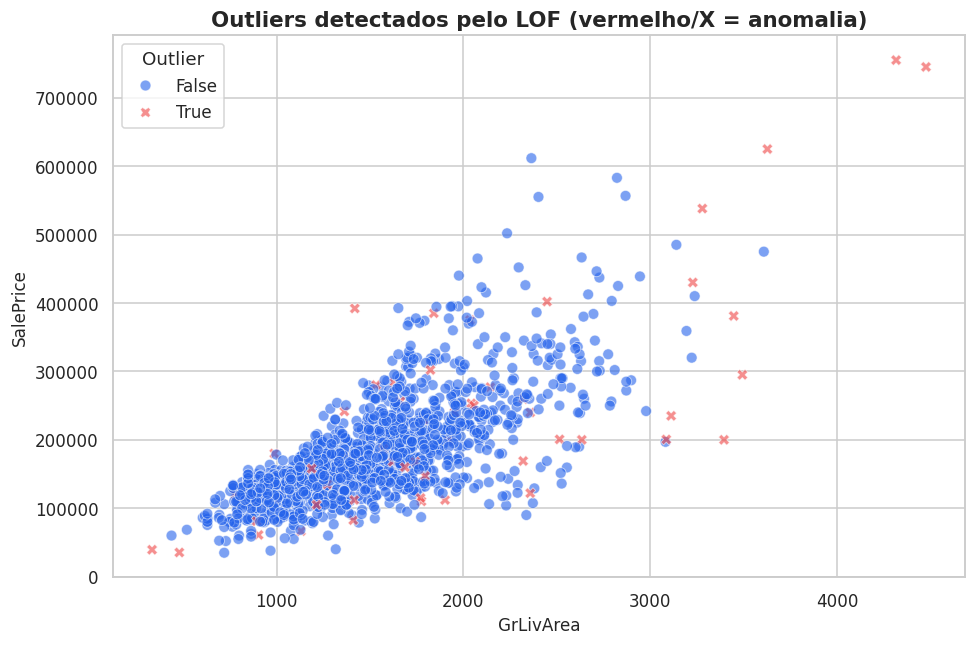


Exemplos de casas anômalas:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,GrLivArea,SalePrice,OverallQual,TotalSF
53,1842,385000,9,3684
114,2320,259500,6,3348
120,988,180000,6,1926
182,1340,120000,5,1340
197,3112,235000,8,4080
249,2144,277000,6,3588
260,1382,176000,6,2744
268,778,120500,5,1518


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
from sklearn.neighbors import LocalOutlierFactor

feat_out = ['TotalSF','OverallQual','GrLivArea','SalePrice','LotArea','GarageArea']
Xout = StandardScaler().fit_transform(dados[feat_out].fillna(dados[feat_out].median()))

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.04)
flag = lof.fit_predict(Xout)
dados['Outlier'] = (flag == -1)

n_out = dados['Outlier'].sum()
print(f'Casas sinalizadas como outliers: {n_out} ({n_out/len(dados)*100:.1f}%)')

plt.figure(figsize=(9, 6))
sns.scatterplot(data=dados, x='GrLivArea', y='SalePrice', hue='Outlier',
                palette={False:PALETTE[0], True:PALETTE[3]}, alpha=.6,
                style='Outlier', markers={False:'o', True:'X'}, s=50)
plt.title('Outliers detectados pelo LOF (vermelho/X = anomalia)')
plt.tight_layout(); plt.show()

print('\nExemplos de casas anômalas:')
dados[dados['Outlier']][['GrLivArea','SalePrice','OverallQual','TotalSF']].head(8)

**Insight:** o LOF identifica casas com combinações incomuns — por exemplo, área enorme com preço baixo, ou qualidade altíssima num lote pequeno. Em um pipeline real, essas casas seriam revisadas (erro de cadastro?) ou tratadas separadamente para não distorcer o modelo.

---
#  8. Comparação Final e Conclusões

## Resumo dos modelos supervisionados

In [33]:
print('='*60)
print('REGRESSÃO (prever o valor em US$)')
print('='*60)
print(tab_reg.to_string(index=False))
print('\n' + '='*60)
print('CLASSIFICAÇÃO (cara vs barata)')
print('='*60)
print(tab_clf.to_string(index=False))

REGRESSÃO (prever o valor em US$)
           Modelo  RMSE (log)  MAE (log)     R²  RMSE (US$)
          XGBoost      0.1228     0.0831 0.9106     19697.0
Gradient Boosting      0.1261     0.0852 0.9057     20278.0
       Lasso (L1)      0.1287     0.0870 0.9018     20813.0
       Ridge (L2)      0.1329     0.0913 0.8953     21664.0
 Regressão Linear      0.1372     0.0935 0.8884     21886.0
    Random Forest      0.1478     0.0985 0.8704     24071.0

CLASSIFICAÇÃO (cara vs barata)
             Modelo  Acurácia  Precisão  Recall    F1   AUC
      Random Forest     0.911     0.941   0.877 0.908 0.981
Regressão Logística     0.887     0.884   0.890 0.887 0.965
  Árvore de Decisão     0.887     0.906   0.863 0.884 0.903
         KNN (k=15)     0.866     0.885   0.842 0.863 0.951


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

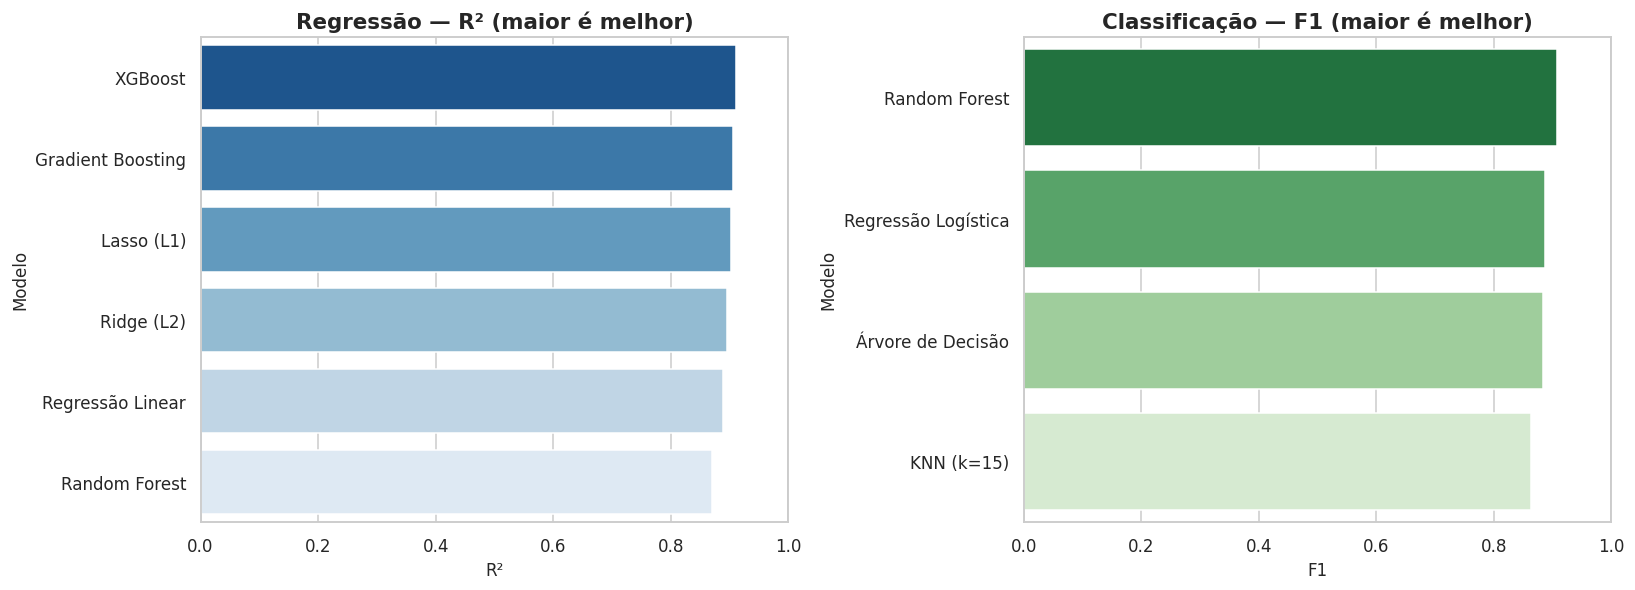

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [34]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.barplot(data=tab_reg, y='Modelo', x='R²', palette='Blues_r', ax=axes[0])
axes[0].set_title('Regressão — R² (maior é melhor)'); axes[0].set_xlim(0,1)
sns.barplot(data=tab_clf, y='Modelo', x='F1', palette='Greens_r', ax=axes[1])
axes[1].set_title('Classificação — F1 (maior é melhor)'); axes[1].set_xlim(0,1)
plt.tight_layout(); plt.show()

##  A história completa, em uma frase

Partimos de **1.460 casas e 79 características brutas** e, percorrendo todo o ciclo de ciência de dados, descobrimos que **qualidade e tamanho são os grandes determinantes do preço**.

### O que cada etapa nos contou:

| Técnica | Resultado | O que aprendemos |
|---------|-----------|------------------|
| 🔎 **EDA** | `OverallQual` e `GrLivArea` lideram a correlação | *Qualidade e área importam mais que tudo* |
| 🛠️ **Feature Engineering** | `TotalSF` (corr ≈ 0,83) supera variáveis originais | *Criar variáveis certas vale mais que ter muitas* |
| 📈 **Regressão** | Gradient Boosting / XGBoost com **R² ≈ 0,90** | *Conseguimos prever o preço com erro de ~US\$ 20k* |
| 🎯 **Classificação** | Regressão Logística com **~93% acurácia, AUC ≈ 0,98** | *Separar cara/barata é quase linear* |
| 🧩 **Clusterização** | 3 perfis: Econômicas, Padrão, Premium | *O mercado tem segmentos naturais* |
| 🔬 **PCA** | 2 componentes já organizam o preço em diagonal | *200 colunas escondem poucas dimensões reais* |
| 🔗 **Apriori** | "Alta qualidade + grande → caro" | *Regras interpretáveis confirmam os modelos* |
| 🚨 **LOF** | ~4% de casas anômalas | *Toda base real tem pontos fora da curva* |

###  Entregamos todas as 7 tarefas do desafio com modelos avaliados, comparados e visualizados.

> *Mais do que prever números, este projeto mostra o **raciocínio** de um cientista de dados: explorar, transformar, modelar, validar e — acima de tudo — **contar a história** que os dados revelam.*

---
*Fim do notebook — Desafio C3 · House Prices · Ames, Iowa.*